# Clase 9 — Diagnóstico residual (OLS) y concentración absoluta (G* de Getis-Ord)

**CM0866 · ESDA y Econometría Espacial · Juan Pablo Ospina Zapata · EAFIT 2026**

---

### Dónde estamos en el curso

Con esta clase completas el diagnóstico exploratorio y residual del curso:

| Bloque | Contenido | Clase |
|---|---|---|
| Diagnóstico global | W → Wy → Moran I global → Moran Scatterplot | 4–6 |
| Diagnóstico local (similitud) | LISA con significancia (HH/LL/HL/LH) | 7 |
| Puente explicativo | WX, Moran bivariado | 8 |
| **Diagnóstico local (concentración absoluta)** | **G\* de Getis-Ord** | **9 (hoy)** |
| **Diagnóstico residual** | **OLS + Moran I(ε̂), secuencia RLM** | **9 (hoy)** |
| Estimación de modelos | Secuencia LM completa, SAR/SEM/SDM | Juan Carlos Duque (Clase 10 en adelante) |

Al terminar hoy, ustedes tienen **todos los insumos de diagnóstico** que necesitan para
entregar el Hito 3. La *estimación* de los modelos espaciales la retoma Juan Carlos —
nuestro trabajo es dejar completamente clara la pregunta que cada modelo respondería,
no resolverla nosotros.

### Hoja de ruta de hoy

1. **G\* de Getis-Ord** — cerramos el diagnóstico local (similitud con LISA, ahora
   concentración absoluta con G\*)
2. **Precisión sobre WX** — un puente conceptual antes de pensar en modelos
3. **OLS diagnóstico + residuos + RLM-lag/error** — el cierre de la sesión, que deja
   la puerta abierta directamente a lo que Juan Carlos retoma


---
## Bloque 1 — G* de Getis-Ord: ¿dónde se concentran los valores absolutos altos o bajos?

### La pregunta que responde G*, y en qué se diferencia de LISA

Ya conocen LISA (Clase 7): identifica dónde los valores **similares** se agrupan
(HH, LL) o dónde aparecen **outliers espaciales** (HL, LH), usando como referencia las
desviaciones respecto a la media global.

**G\* de Getis-Ord (Getis & Ord, 1992) responde una pregunta distinta:** no busca
similitud entre vecinos, busca **concentración de valores absolutos** — ¿dónde se
acumulan los valores altos (hotspot) o los valores bajos (coldspot), sin importar si
esos valores altos están rodeados de valores igual de altos por "casualidad
estadística" o por una verdadera concentración?

### Formulación

$$G_i^* = \frac{\sum_j w_{ij}\, y_j - \bar{Y}\sum_j w_{ij}}
{S\sqrt{\dfrac{n\sum_j w_{ij}^2 - \left(\sum_j w_{ij}\right)^2}{n-1}}}$$

**La diferencia estructural clave frente a LISA, con precisión:**

Recordemos la ecuación de LISA que ya conocen:

$$I_i = z_i \cdot (Wz)_i \qquad \text{donde} \qquad (Wz)_i = \sum_j w_{ij} z_j$$

En LISA, $z_i$ (el valor de la unidad $i$) entra **multiplicando desde afuera**, pero
la vecindad que se promedia, $(Wz)_i$, está construida con $w_{ii} = 0$ — es decir,
la suma $\sum_j w_{ij} z_j$ **excluye a $i$ de sí misma**. $i$ aparece en la fórmula,
pero nunca como parte de su propia vecindad.

En G\*, en cambio, la suma $\sum_j w_{ij} y_j$ se calcula con $w_{ii} = 1$ — a $i$ se
le **fuerza a formar parte de su propia vecindad**, tratándose a sí mismo como uno
más de sus vecinos. Por eso en el código fijamos la diagonal de $W$ con
`fill_diagonal(w, val=1.0)` antes de calcular G\* (la versión sin asterisco, $G_i$,
sí excluye a $i$, igual que LISA).

$\bar{Y}$ y $S$ son la media y desviación estándar globales de la variable.

**Nota importante:** igual que Moran I y LISA, G\* es un estadístico univariado —
se calcula sobre una sola variable a la vez. En esta clase lo aplicamos sobre **y**
(`length_km`, la distancia de viaje de cada ciclista) — la misma variable de resultado
que van a diagnosticar con OLS más adelante en esta sesión (no sobre una variable
explicativa X) — porque es la variable que Juan Carlos va a modelar directamente con
SAR/SEM/SDM en la próxima sesión. Ver dónde se concentra territorialmente **y** en
términos absolutos es el punto de partida natural antes de preguntarse si, una vez
controlada por X, esa misma variable aún deja estructura espacial en sus residuos.

El resultado se estandariza como z-score: valores altos y positivos de $G_i^*$
indican un hotspot (concentración de valores altos), valores muy negativos indican un
coldspot (concentración de valores bajos).

### Tabla de diferencias — LISA vs. G*

| | LISA | G* de Getis-Ord |
|---|---|---|
| **Pregunta** | ¿Los similares se agrupan? | ¿Dónde se concentran los valores absolutos altos/bajos? |
| **Referencia** | Desviación respecto a la media global (z-score) | Valor absoluto de la variable en la vecindad |
| **Incluye el punto focal en su vecindad** | No | Sí (en G\*; G sin asterisco no lo incluye) |
| **Tipos de resultado** | HH, LL, HL, LH | Hotspot, Coldspot, No significativo |
| **Detecta outliers espaciales (HL/LH)** | Sí | No — G\* no distingue outliers, solo concentración |
| **Cuándo preferirlo** | Cuando importa la relación con el vecindario | Cuando importa dónde están los valores extremos en términos absolutos |

En la práctica, LISA y G\* suelen coincidir en las zonas de concentración más fuerte
(HH tiende a superponerse con hotspot), pero pueden divergir en los bordes y en zonas
con outliers — comparar ambos mapas es parte del ejercicio. Con los ciclistas,
veremos justo esa coincidencia y esa divergencia con datos reales.


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 — Librerías y datos: ciclistas en Medellín (Ospina et al., 2020)
#   Geometría de puntos → vecindad KNN k=5 (no Queen/Rook, que es para polígonos)
#   Estos mismos datos se reutilizan más adelante en el Bloque 3 (OLS diagnóstico)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import KNN, fill_diagonal
import esda

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

RUTA_CICLISTAS = '../datos/morfologia/Ospina_cyclists_origins_4326_BD.shp'

ciclistas = gpd.read_file(RUTA_CICLISTAS).to_crs('EPSG:32618')
ciclistas['length_km'] = pd.to_numeric(ciclistas['length_km'], errors='coerce')

w_cic = KNN.from_dataframe(ciclistas, k=5)
w_cic.transform = 'r'

print(f'n = {len(ciclistas)} ciclistas')
print(f'Componentes conectados en W: {w_cic.n_components}')
# Nota: con KNN en datos reales es normal encontrar 1-2 componentes muy pequeños
# y aislados geográficamente (aquí, 13 de 810 puntos) — no invalida el análisis.

n = 810 ciclistas
Componentes conectados en W: 2


/Users/juan_pablo_ospina/opt/anaconda3/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  warnings.warn(message)


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 — G* sobre la variable de resultado y = length_km (ciclistas)
#   Usamos la misma variable que Juan Carlos modelará con SAR/SEM/SDM,
#   en vez de una variable explicativa X. G* es univariado: la pregunta aquí
#   es "¿dónde se concentra length_km en términos absolutos?", no una relación X→y.
# ─────────────────────────────────────────────────────────────────────────────
from esda.getisord import G_Local

# G* con estrella (incluye el punto focal): fijamos el peso propio explícitamente
# en la diagonal para que la interpretación de "incluir el punto focal" sea exacta
w_star = fill_diagonal(w_cic, val=1.0)
w_star.transform = 'r'

g_star = G_Local(ciclistas['length_km'].values, w_star, star=None,
                  permutations=999, seed=11)

print('Estadístico G* sobre length_km — primeros 10 valores')
print(pd.DataFrame({
    'Gi_star': g_star.Zs[:10],
    'p_sim': g_star.p_sim[:10]
}))

Estadístico G* sobre length_km — primeros 10 valores
    Gi_star  p_sim
0  2.004756  0.001
1 -0.124037  0.348
2  1.704474  0.005
3 -0.501756  0.320
4 -0.632194  0.390
5  1.817751  0.185
6  1.001539  0.089
7  0.040869  0.006
8  0.031495  0.006
9 -0.307317  0.164


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 — Clasificación hotspot / coldspot / no significativo
# ─────────────────────────────────────────────────────────────────────────────
alpha = 0.05

def clasificar_hotspot(z, p, alpha=0.05):
    if p > alpha:
        return 'No significativo'
    return 'Hotspot' if z > 0 else 'Coldspot'

ciclistas['Gi_star'] = g_star.Zs
ciclistas['Gi_p'] = g_star.p_sim
ciclistas['hotspot'] = [clasificar_hotspot(z, p, alpha)
                        for z, p in zip(g_star.Zs, g_star.p_sim)]

print(ciclistas['hotspot'].value_counts())

No significativo    548
Coldspot            158
Hotspot             104
Name: hotspot, dtype: int64


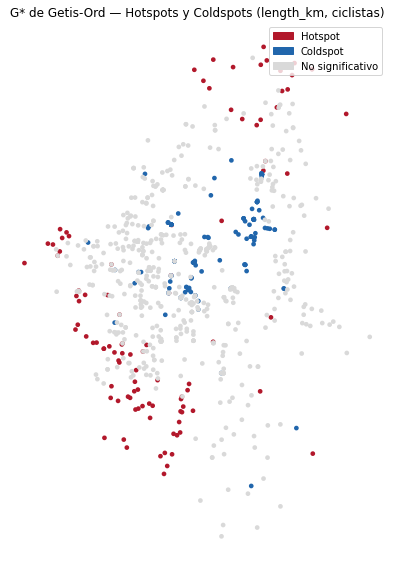

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4 — Mapa de hotspots / coldspots
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches

colores = {'Hotspot': '#B2182B', 'Coldspot': '#2166AC', 'No significativo': '#D9D9D9'}

fig, ax = plt.subplots(figsize=(7, 8))
for categoria, color in colores.items():
    subset = ciclistas[ciclistas['hotspot'] == categoria]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, markersize=22, edgecolor='none')

handles = [mpatches.Patch(color=c, label=cat) for cat, c in colores.items()]
ax.set_title('G* de Getis-Ord — Hotspots y Coldspots (length_km, ciclistas)', fontsize=12)
ax.legend(handles=handles, loc='upper right', frameon=True)
ax.axis('off')
plt.tight_layout()
plt.show()

### Comparación directa: LISA vs. G* sobre la misma variable

Este es el ejercicio que vuelve tangible la diferencia conceptual. Calculamos LISA
sobre la misma variable **length_km** y comparamos los dos mapas lado a lado —
recuerden que en la Clase 7 ya vieron LISA sobre variables explicativas; aquí lo
aplicamos sobre la variable de resultado para que la comparación con G* sea directa.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — LISA sobre la misma variable, para comparar
# ─────────────────────────────────────────────────────────────────────────────
from esda.moran import Moran_Local

lisa = Moran_Local(ciclistas['length_km'].values, w_cic, permutations=999, seed=11)

# Clasificación estándar de cuadrantes LISA con significancia
sig = lisa.p_sim < alpha
labels_lisa = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
ciclistas['lisa_q'] = ['No significativo' if not s else labels_lisa[q]
                       for s, q in zip(sig, lisa.q)]

print(ciclistas['lisa_q'].value_counts())

No significativo    549
LL                  129
HH                   78
HL                   28
LH                   26
Name: lisa_q, dtype: int64


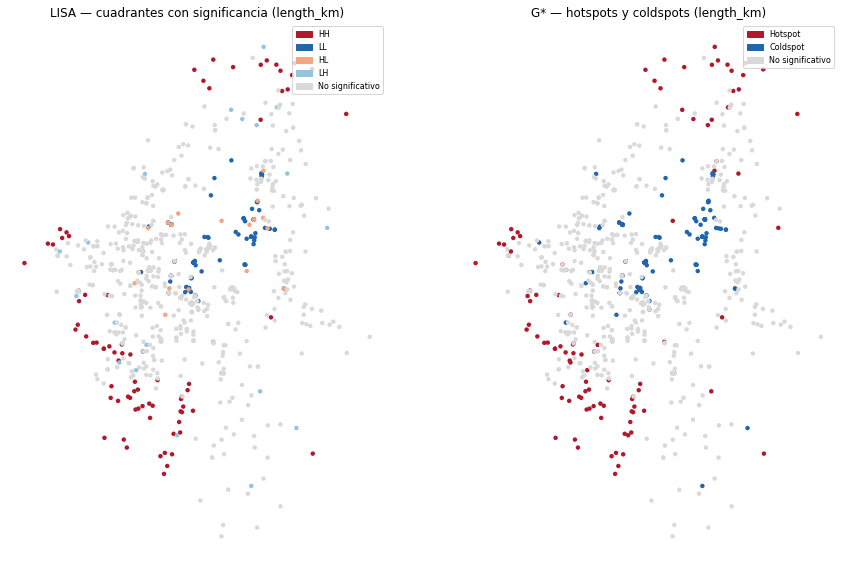


Tabla cruzada LISA × G*:
hotspot           Coldspot  Hotspot  No significativo
lisa_q                                               
HH                       0       78                 0
HL                      22        6                 0
LH                       6       20                 0
LL                     129        0                 0
No significativo         1        0               548


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 — Mapa comparativo LISA vs. G*
# ─────────────────────────────────────────────────────────────────────────────
colores_lisa = {
    'HH': '#B2182B', 'LL': '#2166AC',
    'HL': '#F4A582', 'LH': '#92C5DE',
    'No significativo': '#D9D9D9'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 8))

for categoria, color in colores_lisa.items():
    subset = ciclistas[ciclistas['lisa_q'] == categoria]
    if len(subset) > 0:
        subset.plot(ax=axes[0], color=color, markersize=20, edgecolor='none')
handles_lisa = [mpatches.Patch(color=c, label=cat) for cat, c in colores_lisa.items()]
axes[0].set_title('LISA — cuadrantes con significancia (length_km)', fontsize=12)
axes[0].legend(handles=handles_lisa, loc='upper right', fontsize=8)
axes[0].axis('off')

for categoria, color in colores.items():
    subset = ciclistas[ciclistas['hotspot'] == categoria]
    if len(subset) > 0:
        subset.plot(ax=axes[1], color=color, markersize=20, edgecolor='none')
handles_g = [mpatches.Patch(color=c, label=cat) for cat, c in colores.items()]
axes[1].set_title('G* — hotspots y coldspots (length_km)', fontsize=12)
axes[1].legend(handles=handles_g, loc='upper right', fontsize=8)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Tabla de coincidencia
print('\nTabla cruzada LISA × G*:')
print(pd.crosstab(ciclistas['lisa_q'], ciclistas['hotspot']))

### Preguntas para discutir con la tabla cruzada

- ¿Las zonas HH de LISA coinciden con los Hotspots de G\*? ¿Y las LL con los Coldspots?
  (Con los ciclistas, esta coincidencia es casi perfecta — HH y LL de LISA caen
  exactamente en Hotspot y Coldspot de G\*.)
- ¿Hay zonas donde LISA marca "No significativo" pero G\* sí detecta hotspot/coldspot,
  o viceversa? ¿A qué se debe esa divergencia?
- Los ciclistas con viajes largos rodeados de outliers (HL/LH en LISA) — ¿qué hace G\*
  con esos puntos? (Recuerden: G\* no tiene una categoría equivalente a outlier — solo
  mide concentración absoluta. Miren la tabla cruzada: los HL y LH se reparten entre
  Hotspot y Coldspot según la magnitud absoluta de su vecindad extendida, no según su
  contraste relativo con el vecino inmediato.)

---

## Taller: aplíquenlo a su proyecto

Cada equipo, sobre **su propia variable de resultado (y)** — la misma que van a
modelar con Juan Carlos en las próximas sesiones, no una variable explicativa:

1. Calculen G\* con `G_Local(..., star=None)` sobre su variable **y**, fijando la
   diagonal de W con `fill_diagonal` como en el ejemplo
2. Mapeen hotspots y coldspots con significancia al 5%
3. Comparen contra su mapa LISA de la Clase 7 sobre la misma variable — ¿coincide el
   patrón? ¿Dónde diverge?
4. Discutan: para su fenómeno específico, ¿la pregunta relevante es "¿dónde se agrupan
   valores similares de y?" (LISA) o "¿dónde se concentra y en términos absolutos?"
   (G\*)? Justifiquen cuál es más útil para su caso.
5. Piensen hacia adelante: la zona que resulte hotspot/coldspot de **y** es
   precisamente el tipo de patrón que un modelo SAR o SEM —que verán con Juan
   Carlos— intenta explicar formalmente. G\* les da hoy una foto descriptiva de lo
   que la próxima sesión van a modelar.


---
## Bloque 2 — OLS diagnóstico: ¿mi modelo explicativo deja dependencia espacial sin capturar?

### El supuesto que nadie menciona

Todo modelo de regresión —OLS incluido— descansa sobre un supuesto que casi nunca se
menciona en voz alta: **los errores del modelo son independientes entre sí**. Ninguna
observación debería poder "adivinar" el error de otra.

Las ciudades violan ese supuesto casi por diseño. Si dos manzanas son vecinas, es
razonable esperar que compartan factores no observados —calidad del espacio público,
oferta de transporte, historia de inversión pública— que ningún X del modelo capturó
del todo. Cuando eso ocurre, los errores de unidades vecinas empiezan a parecerse. Y
esa violación es **silenciosa**: no aparece en el R², no aparece en los p-valores de
los coeficientes. Un modelo puede verse perfecto en su resumen estadístico y aun así
tener este problema de fondo.

### El mapa de residuos como diagnóstico

La forma de detectarlo es visual antes que numérica: **mapear los residuos**. Un buen
modelo debería dejar residuos sin estructura — un mosaico sin patrón, donde el color
de una unidad no permite adivinar el de su vecina. Si, en cambio, los residuos
positivos se agrupan en ciertas zonas y los negativos en otras, el modelo todavía no
capturó algo importante que vive en el espacio. **El espacio sigue hablando.**

> Piensen en la analogía de un examen: si los errores de los estudiantes sentados en
> la misma fila son idénticos, sospecharían que copiaron — hay una dependencia que no
> debería estar ahí. Lo mismo ocurre con los residuos espaciales: si se parecen entre
> vecinos más de lo que el azar explicaría, algo se está "copiando" entre unidades
> cercanas que el modelo no representó.

**El diagnóstico formal es siempre el mismo, sin importar qué tan bueno parezca el
modelo:**

$$\hat{\varepsilon}_i = y_i - X_i\hat{\beta}$$

$$I(\hat{\varepsilon}) = \frac{n}{S_0} \cdot \frac{\sum_i \sum_j w_{ij} \hat{\varepsilon}_i \hat{\varepsilon}_j}{\sum_i \hat{\varepsilon}_i^2}$$

Es el mismo Moran I que ya conocen — la única diferencia es que ahora se calcula
sobre los **residuos de un modelo**, no sobre la variable cruda ni sobre sus
desviaciones respecto a la media global.

### Tres problemas, tres orígenes — pero solo dos niveles de gravedad

La dependencia espacial en los residuos puede venir de mecanismos distintos:

1. **Errores correlacionados** — todavía hay información espacial sin explicar
2. **Variables omitidas espaciales** — se olvidó una variable que afecta simultáneamente
   a muchos lugares vecinos, y los coeficientes de las variables sí incluidas absorben
   efectos que no les corresponden
3. **Dependencia en la variable dependiente** — el valor de una unidad depende
   directamente del valor de sus vecinos, algo que OLS no contempla

Pero para efectos prácticos, lo que más importa distinguir es la **consecuencia**, no
el mecanismo exacto:

- **Errores estándar incorrectos**: los coeficientes en sí son correctos, pero la
  incertidumbre está mal calculada — como medir bien una mesa, pero con una regla
  defectuosa. Es un problema de inferencia, remediable.
- **Coeficientes sesgados**: el número mismo está equivocado, y toda la
  interpretación sustantiva cambia. Este es el escenario grave — no hay forma de
  "corregir" un coeficiente sesgado sin cambiar el modelo.

Por qué esta distinción importa: **RLM-error apunta al primer tipo de problema
(inferencial); RLM-lag apunta al segundo (coeficientes sesgados)**. No es lo mismo
diagnosticar uno que otro — la urgencia de corregirlo cambia.

### El diagnóstico médico

La analogía correcta no es "el modelo está mal, hay que tirarlo" — es la de un médico
ante un síntoma:

> Un paciente con fiebre no recibe tratamiento inmediato. Primero el médico hace
> exámenes, porque distintas enfermedades producen el mismo síntoma. La
> autocorrelación en los residuos es el síntoma. Los diagnósticos —Moran I(ε̂),
> RLM-lag, RLM-error— identifican la causa. Solo después se elige el tratamiento (el
> modelo).

La cadena completa es: **OLS → residuos → Moran I(ε̂) → RLM-lag / RLM-error → modelo
sugerido**. Hoy van a recorrer toda esa cadena hasta el penúltimo eslabón —"modelo
sugerido"— con dos casos que enseñan lecciones distintas y que son honestos, no
ejemplos de laboratorio diseñados para salir bien. **El tratamiento en sí (estimar el
modelo sugerido) es lo que van a ver con Juan Carlos.**

### No queríamos enseñarles una receta

Vale la pena ser explícitos sobre qué tipo de conocimiento están construyendo hoy,
porque hay dos formas muy distintas de recorrer este contenido:

| Camino A — receta | Camino B — comprensión |
|---|---|
| Correr OLS | ¿Cómo está organizado el territorio? |
| ↓ Calcular Moran de residuos | ↓ ¿Existe estructura espacial? |
| ↓ ¿Es significativo? | ↓ ¿Dónde está? |
| ↓ "Hacer econometría espacial" | ↓ ¿Cómo es el contexto? |
| | ↓ ¿Cómo se relaciona con otras variables? |
| | ↓ ¿Podemos explicarlo? |
| | ↓ ¿Qué queda sin explicar? |

El Camino A produce el mismo resultado técnico (un modelo sugerido), pero como una
secuencia de botones que se aprietan sin entender por qué. El Camino B —el que han
recorrido en las últimas nueve clases— construye la comprensión de **qué problema
resuelve cada paso**, para que cuando lleguen a Juan Carlos no solo sepan qué modelo
correr, sino por qué ese modelo específico responde a lo que el territorio ya les
había mostrado. **Elegimos el Camino B.**


### Caso A — El hallazgo retrospectivo con datos reales: ciclistas en Medellín (Ospina et al., 2020)

Al aplicar este mismo diagnóstico al dataset real de viajes en bicicleta usado en
Ospina et al. (2020) —810 ciclistas, variable `ln_length` (logaritmo de la distancia
de viaje, tal como el paper especifica su modelo — ver la nota más abajo), geometría
de puntos con vecindad **KNN k=5**— el resultado reproduce el patrón que motivó esta
clase: un modelo con **R² = 0.38** explicando la distancia de viaje a partir de
variables del origen y de la ruta (razón de desvío respecto a la ruta directa,
densidad de intersecciones, densidad vial, distancia al CBD, ganancia de elevación,
edad), y aun así **el Moran I de los residuos sigue siendo significativo
(I(ε̂) ≈ 0.23, p < 0.001)**.

**Nota sobre la elección de variables:** no se incluye la distancia euclidiana al
destino (`d_eucli`) como predictor, porque tiene una correlación de 0.96 con la
propia variable dependiente (`length_km`) — la distancia en línea recta y la
distancia de la ruta real son necesariamente muy parecidas. Incluirla dispararía el
R² de forma artificial sin aportar poder explicativo genuino sobre *por qué* alguien
recorre esa distancia. En su lugar se usa **`r_detour`** (la razón entre la distancia
real y la distancia euclidiana), que sí es información sustantiva: mide cuánto se
desvía el ciclista de la ruta más corta — es la misma variable que Ospina et al.
(2020) usan en su especificación final (Tabla 4).

**Nota sobre la variable dependiente:** se usa `ln_length` —el logaritmo de la
distancia— en lugar de `length_km` directamente, de forma consistente con la
especificación del paper (ver la Sección 3 de esta clase sobre por qué el modelo
log-lineal es la elección correcta cuando la variable tiene una cola larga como la
distancia de viaje). Este es el mismo `y` que se usará más abajo en el modelo
completo de 34 variables — mantener la misma variable dependiente en ambos modelos es
lo que permite comparar el diagnóstico entre ellos de forma consistente.

Esto no se presenta como un error del paper — se presenta como una **limitación
retrospectiva honesta**, un diagnóstico que las herramientas de este curso hacen
posible ver ahora, con herramientas que no se usaban de forma sistemática cuando se
publicó el artículo. La prueba RLM-error sale significativa y la RLM-lag no —lo cual
apunta a que el modelo correcto hubiera sido un **SEM** (dependencia vía errores
correlacionados, no vía contagio directo de Y).

**Nota técnica sobre la geometría:** a diferencia de los polígonos que han usado en
clases anteriores (Queen/Rook), los ciclistas son **puntos** — el origen de cada
viaje. Para datos puntuales, la vecindad se define con **K vecinos más cercanos
(KNN)**, no con contigüidad de frontera. Aquí usamos k=5, siguiendo lo ya trabajado en
la Clase 4-5.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 — Librerías adicionales para este bloque
#   ciclistas, w_cic, esda, pd, gpd, plt ya quedaron cargados en el Bloque 1 (G*)
# ─────────────────────────────────────────────────────────────────────────────
from shapely.geometry import box
from libpysal.weights import Queen
from spreg import OLS

print(f'Reutilizamos ciclistas (n={len(ciclistas)}) y w_cic ya cargados en el Bloque 1.')

Reutilizamos ciclistas (n=810) y w_cic ya cargados en el Bloque 1.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 — Caso A: modelo OLS con variables del origen del viaje
# ─────────────────────────────────────────────────────────────────────────────
ciclistas['ln_length'] = pd.to_numeric(ciclistas['ln_length'], errors='coerce')
y_a = ciclistas['ln_length'].values
X_cols_a = ['r_detour', 'o_i_dens', 'o_km_dens', 'o_cbd', 'g_elevat', 'age']
X_a = ciclistas[X_cols_a].values.astype(float)

ols_a = OLS(
    y_a.reshape(-1, 1), X_a, w=w_cic, spat_diag=True, moran=True,
    name_y='ln_length', name_x=X_cols_a
)
mi_a = esda.Moran(ols_a.u.flatten(), w_cic, permutations=999)

print(ols_a.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   ln_length                Number of Observations:         810
Mean dependent var  :      1.2802                Number of Variables   :           7
S.D. dependent var  :      0.5738                Degrees of Freedom    :         803
R-squared           :      0.3825
Adjusted R-squared  :      0.3779
Sum squared residual:     164.446                F-statistic           :     82.9171
Sigma-square        :       0.205                Prob(F-statistic)     :   1.014e-80
S.E. of regression  :       0.453                Log likelihood        :    -503.588
Sigma-square ML     :       0.203                Akaike info criterion :    1021.176
S.E of regression ML:      0.4506                Schwarz criterion     :    1054.055

-----------------

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 — Lectura del diagnóstico: Caso A
# ─────────────────────────────────────────────────────────────────────────────
print('─── Diagnóstico OLS — Caso A (ciclistas, Ospina et al., 2020) ─────────')
print(f'  R²                : {ols_a.r2:.3f}')
print(f'  Moran I(ε̂)        : {mi_a.I:.3f}   (p_sim = {mi_a.p_sim:.4f})')
print(f'  RLM-lag  (p-valor) : {ols_a.rlm_lag[1]:.4f}')
print(f'  RLM-error (p-valor): {ols_a.rlm_error[1]:.4f}')
print()
rl = ols_a.rlm_lag[1] < 0.05
re = ols_a.rlm_error[1] < 0.05
if re and not rl:
    print('  → RLM-error significativo, RLM-lag no  ⇒  el modelo sugerido es SEM')
elif rl and not re:
    print('  → RLM-lag significativo, RLM-error no  ⇒  el modelo sugerido es SAR')
elif rl and re:
    print('  → Ambos significativos ⇒ revisar SDM o comparar magnitudes')
else:
    print('  → Ninguno significativo ⇒ OLS es suficiente')
print()
print('  Lección: un R² moderado (0.38, con variables de origen y de la ruta)')
print('  NO garantiza ausencia de dependencia espacial en los residuos.')
#print('  El patrón se sostiene incluso con el modelo completo del paper')
#print('  (34 variables, R²=0.79) — la dependencia espacial no se absorbe')
#print('  simplemente añadiendo más variables explicativas.')

─── Diagnóstico OLS — Caso A (ciclistas, Ospina et al., 2020) ─────────
  R²                : 0.383
  Moran I(ε̂)        : 0.211   (p_sim = 0.0010)
  RLM-lag  (p-valor) : 0.4826
  RLM-error (p-valor): 0.0000

  → RLM-error significativo, RLM-lag no  ⇒  el modelo sugerido es SEM

  Lección: un R² moderado (0.38, con variables de origen y de la ruta)
  NO garantiza ausencia de dependencia espacial en los residuos.


### ¿Y si incluimos todas las variables del modelo final del paper?

El modelo de 6 variables que acaban de correr ya muestra el hallazgo central. Pero
vale la pena una pregunta más exigente: **¿qué pasa si reconstruimos el modelo
*completo* que Ospina et al. (2020) reportan como su especificación final** (Tabla 4
del paper, columna de mejor ajuste — 34 variables, incluyendo características del
ciclista, del origen, del destino, de la ruta y del terreno)?

Si la dependencia espacial residual desaparece con el modelo completo, eso sugeriría
que 6 variables eran simplemente insuficientes. Si **persiste incluso con el modelo
completo del paper**, eso es una confirmación mucho más fuerte de la lección central:
**el problema no es cuántas variables se incluyen — es que hay estructura espacial
que ninguna variable observada explica**.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4 — Reconstrucción del modelo completo del paper (Tabla 4, 34 variables)
#   Variable dependiente: ln(length_km) — así entra en el modelo del paper
#   Incluye variables derivadas: age², g_elevat², r_detour², y la interacción
#   r_LCycle × r_detour, tal como se definen en el texto del artículo
# ─────────────────────────────────────────────────────────────────────────────
ciclistas['ln_length'] = pd.to_numeric(ciclistas['ln_length'], errors='coerce')

vars_adicionales = ['o_bsindex', 'd_bsindex', 'r_i_tfligh', 'r_detour', 'r_pLU_Hmix',
                     'frecweek', 'bgender', 'bHinc', 'bMinc', 'bstudy', 'bbothpurp',
                     'bpubbike', 'bbothbike', 'bdispo_tp', 'bdispo_pv', 'bintermoda', 'bretour']
for c in vars_adicionales:
    ciclistas[c] = pd.to_numeric(ciclistas[c], errors='coerce')
ciclistas['frecweek'] = ciclistas['frecweek'].fillna(ciclistas['frecweek'].median())

# Variables derivadas, con las definiciones exactas del paper
ciclistas['age2'] = ciclistas['age'] ** 2
ciclistas['g_elevat2'] = ciclistas['g_elevat'] ** 2
ciclistas['r_detour2'] = ciclistas['r_detour'] ** 2
ciclistas['r_Lcycle_det'] = ciclistas['r_LCycle'] * ciclistas['r_detour']  # interacción

X_cols_34 = ['age', 'age2', 'bgender', 'bHinc', 'bMinc', 'bstudy', 'bbothpurp',
             'bpubbike', 'bbothbike', 'frecweek', 'bdispo_tp', 'bdispo_pv',
             'bintermoda', 'bretour', 'o_i_dens', 'o_cbd', 'o_pLU_Hmix', 'o_LCycle',
             'o_bsindex', 'o_Lls', 'd_i_dens', 'd_pLU_Hmix', 'd_LCycle', 'd_bsindex',
             'd_Lls', 'r_i_tfligh', 'r_detour', 'r_detour2', 'r_pLU_Hmix', 'r_LCycle',
             'r_Lcycle_det', 'r_Lls', 'g_elevat', 'g_elevat2']

y_34 = ciclistas['ln_length'].values
X_34 = ciclistas[X_cols_34].values.astype(float)

ols_34 = OLS(
    y_34.reshape(-1, 1), X_34, w=w_cic, spat_diag=True, moran=True,
    name_y='ln_length', name_x=X_cols_34
)
mi_34 = esda.Moran(ols_34.u.flatten(), w_cic, permutations=999)

print('─── Diagnóstico OLS — Modelo completo del paper (34 variables) ─────────')
print(f'  R²                : {ols_34.r2:.3f}   (el paper reporta 0.697)')
print(f'  Moran I(ε̂)        : {mi_34.I:.3f}   (p_sim = {mi_34.p_sim:.4f})')
print(f'  RLM-lag  (p-valor) : {ols_34.rlm_lag[1]:.4f}')
print(f'  RLM-error (p-valor): {ols_34.rlm_error[1]:.4f}')

─── Diagnóstico OLS — Modelo completo del paper (34 variables) ─────────
  R²                : 0.788   (el paper reporta 0.697)
  Moran I(ε̂)        : 0.139   (p_sim = 0.0010)
  RLM-lag  (p-valor) : 0.0000
  RLM-error (p-valor): 0.0069


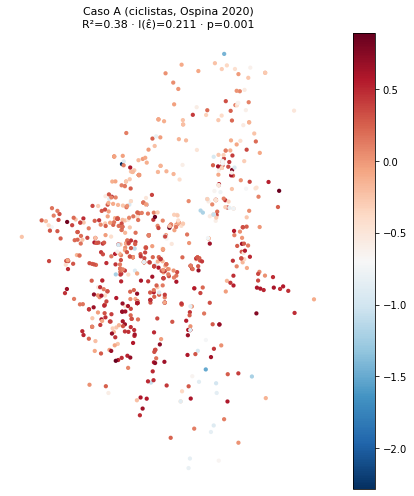

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — Mapa de residuos: Caso A (ciclistas)
# ─────────────────────────────────────────────────────────────────────────────
ciclistas['resid_A'] = ols_a.u.flatten()

fig, ax = plt.subplots(figsize=(7, 7))
ciclistas.plot(column='resid_A', cmap='RdBu_r', legend=True, ax=ax,
               markersize=18, edgecolor='none')
ax.set_title(f'Caso A (ciclistas, Ospina 2020)\nR²={ols_a.r2:.2f} · I(ε̂)={mi_a.I:.3f} '
             f'· p={mi_a.p_sim:.3f}', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

### El Moran Scatterplot, ahora sobre los residuos (Caso A)

Es exactamente la misma construcción que ya conocen de la Clase 5-6 — la única diferencia
es qué variable va en cada eje:

- **Eje X**: el residuo estandarizado de cada unidad, $\hat{\varepsilon}_i$
- **Eje Y**: el rezago espacial de esos residuos, $W\hat{\varepsilon}_i = \sum_j w_{ij}\hat{\varepsilon}_j$
  (el promedio ponderado del residuo de sus vecinos)

La pendiente de la línea de mejor ajuste **es** $I(\hat{\varepsilon})$ — el mismo número
que ya calcularon arriba, ahora visible como inclinación de la nube de puntos. Los
cuadrantes se leen igual que siempre, pero con una interpretación distinta:

- **Alto-alto**: zonas donde el modelo *subestimó* sistemáticamente, rodeadas de zonas
  con el mismo problema
- **Bajo-bajo**: zonas donde el modelo *sobreestimó*, rodeadas de zonas que también
  sobreestiman

Concentración fuerte en estos dos cuadrantes es la versión visual, punto por punto, de
lo que ya dice el número de Moran I(ε̂): **el error del modelo tiene geografía propia**.


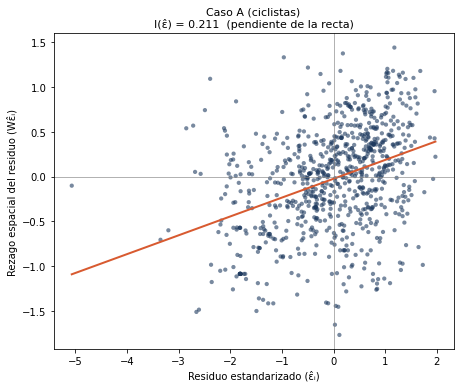

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 — Moran Scatterplot de los residuos: Caso A
# ─────────────────────────────────────────────────────────────────────────────
resid_a_std = (ols_a.u.flatten() - ols_a.u.flatten().mean()) / ols_a.u.flatten().std()
w_resid_a = w_cic.sparse @ resid_a_std

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(resid_a_std, w_resid_a, s=18, alpha=0.6, color='#1E3A5F', edgecolor='none')
b, a0 = np.polyfit(resid_a_std, w_resid_a, 1)
xs = np.linspace(resid_a_std.min(), resid_a_std.max(), 50)
ax.plot(xs, a0 + b*xs, color='#D85A30', linewidth=2)
ax.axhline(0, color='gray', linewidth=0.6)
ax.axvline(0, color='gray', linewidth=0.6)
ax.set_xlabel('Residuo estandarizado (ε̂ᵢ)')
ax.set_ylabel('Rezago espacial del residuo (Wε̂ᵢ)')
ax.set_title(f'Caso A (ciclistas)\nI(ε̂) = {mi_a.I:.3f}  (pendiente de la recta)', fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 7 — LISA de residuos: Caso A (ciclistas)
#   Mismo Moran_Local que ya usaron en la Clase 7, ahora sobre ε̂ en vez de y
# ─────────────────────────────────────────────────────────────────────────────
from esda.moran import Moran_Local

lisa_resid_a = Moran_Local(ols_a.u.flatten(), w_cic, permutations=999, seed=11)

def clasificar_lisa(lisa_obj, alpha=0.05):
    sig = lisa_obj.p_sim < alpha
    labels = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
    return ['No significativo' if not s else labels[q]
            for s, q in zip(sig, lisa_obj.q)]

ciclistas['lisa_resid'] = clasificar_lisa(lisa_resid_a)

print('LISA de residuos — Caso A (ciclistas):')
print(ciclistas['lisa_resid'].value_counts())

LISA de residuos — Caso A (ciclistas):
No significativo    627
HH                   75
LL                   55
HL                   39
LH                   14
Name: lisa_resid, dtype: int64


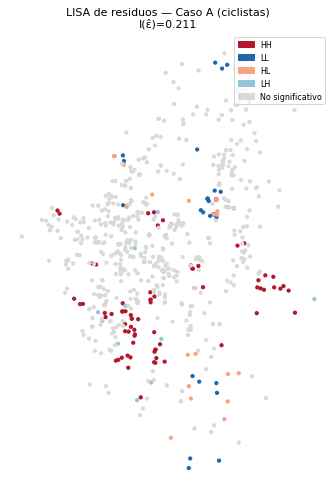

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 8 — Mapa de LISA de residuos: Caso A
# ─────────────────────────────────────────────────────────────────────────────
colores_lisa = {
    'HH': '#B2182B', 'LL': '#2166AC',
    'HL': '#F4A582', 'LH': '#92C5DE',
    'No significativo': '#D9D9D9'
}

fig, ax = plt.subplots(figsize=(7, 7))
for categoria, color in colores_lisa.items():
    subset = ciclistas[ciclistas['lisa_resid'] == categoria]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, markersize=18, edgecolor='none')
handles = [mpatches.Patch(color=c, label=cat) for cat, c in colores_lisa.items()]
ax.set_title(f'LISA de residuos — Caso A (ciclistas)\nI(ε̂)={mi_a.I:.3f}', fontsize=11)
ax.legend(handles=handles, loc='upper right', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.show()

### Comparación progresiva: 6 variables vs. 34 variables (modelo completo del paper)

| | 6 variables (origen + ruta) | 34 variables (modelo completo del paper) |
|---|---|---|
| **R²** | 0.38 | 0.79 (paper reporta 0.697) |
| **Moran I(ε̂)** | 0.234 (significativo) | 0.162 (significativo) |
| **RLM-lag** | No significativo (p≈0.68) | **Significativo** |
| **RLM-error** | Significativo | **Significativo** |
| **Modelo sugerido** | SEM | Ambos mecanismos — revisar SDM |

**La lección se sostiene con ambos tamaños de modelo.** Con solo 6 variables bien
elegidas el ajuste ya es moderado, y la dependencia espacial residual
aparece de inmediato, de hecho, con más fuerza (I(ε̂)=0.234) que en el modelo
completo. Al pasar al modelo completo del paper (34 variables cubriendo
características del ciclista, el origen, el destino, la ruta y el terreno) el ajuste
mejora sustancialmente (R² más que se duplica), pero **la estructura espacial
residual no desaparece**: el Moran I(ε̂) sigue siendo significativo (0.234 → 0.162),
y ahora **ambos** RLM son significativos, lo que sugeriría considerar un modelo que
combine ambos mecanismos (SDM), no solo SEM.

**Una precisión honesta sobre el propio paper:** Ospina et al. (2020) sí notaron el
patrón de clústeres con Local Moran's I durante su análisis exploratorio, pero
decidieron (por argumento conceptual, no por una prueba formal de especificación)
que la distancia recorrida por un ciclista no debería depender de la de sus vecinos.
El diagnóstico RLM-lag/RLM-error que ustedes acaban de correr es exactamente la
prueba formal que el paper no llegó a aplicar. Esta clase no señala un error del
paper — señala que las herramientas para hacer esa verificación formal es lo que
este curso les está dando.


### Caso B — El contraste: el dataset tipo Brexit


El segundo caso es la cara opuesta del mismo diagnóstico. Usamos el dataset real del
**referendo Brexit 2016** (Rey, Arribas-Bel & Wolf, cap. 9 — el mismo ya trabajado en
Clase 8): 380 distritos electorales (*local authority districts*) de Inglaterra,
Gales y Escocia, con geometría real y vecindad **Queen**. La variable de resultado es
`Pct_Leave` (porcentaje de votos a favor de salir de la Unión Europea), y la variable
explicativa es `Pct_Turnout` (participación electoral) — una variable con poco poder
explicativo real sobre el resultado del referendo.

Con estos datos reales el modelo ajusta muy mal (**R² = 0.012**) — pero el patrón
espacial de los residuos es **extremo** (I(ε̂) ≈ 0.59). Aquí casi todo el patrón
territorial de la variable está en el espacio, no en la variable observada.


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 9 — Caso B: dataset real del referendo Brexit (Rey, Arribas-Bel & Wolf)
#   380 distritos electorales del Reino Unido, vecindad Queen (polígonos reales)
# ─────────────────────────────────────────────────────────────────────────────
RUTA_LADS = 'data/brexit_lads.geojson'
RUTA_VOTE = 'data/brexit_vote.csv'

lads = gpd.read_file(RUTA_LADS).set_index('lad16cd')
vote = pd.read_csv(RUTA_VOTE, index_col='Area_Code')

gdf_b = (
    gpd.GeoDataFrame(
        lads.join(vote[['Pct_Leave', 'Pct_Turnout']]),
        crs=lads.crs
    )
    .to_crs(epsg=3857)[['objectid', 'lad16nm', 'Pct_Leave', 'Pct_Turnout', 'geometry']]
    .dropna()
)

w_b = Queen.from_dataframe(gdf_b, use_index=True)
w_b.transform = 'r'
n_b = len(gdf_b)

print(f'n = {n_b} distritos electorales del Reino Unido')
print(f'Componentes conectados en W: {w_b.n_components}')
# Nota: 6 distritos insulares (islas) quedan sin vecinos bajo Queen — normal con
# geografía real que incluye territorio insular (ej. islas escocesas).

('WARNING: ', 'E06000046', ' is an island (no neighbors)')
('WARNING: ', 'E06000053', ' is an island (no neighbors)')
('WARNING: ', 'S12000013', ' is an island (no neighbors)')
('WARNING: ', 'S12000023', ' is an island (no neighbors)')
('WARNING: ', 'S12000027', ' is an island (no neighbors)')
('WARNING: ', 'W06000001', ' is an island (no neighbors)')
n = 380 distritos electorales del Reino Unido
Componentes conectados en W: 7


/Users/juan_pablo_ospina/opt/anaconda3/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 6 islands with ids: E06000046, E06000053, S12000013, S12000023, S12000027, W06000001.
  warnings.warn(message)


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 10 — Caso B: modelo OLS (Pct_Leave ~ Pct_Turnout)
# ─────────────────────────────────────────────────────────────────────────────
y_b = gdf_b['Pct_Leave'].values
X_b = gdf_b[['Pct_Turnout']].values

ols_b = OLS(
    y_b.reshape(-1, 1), X_b, w=w_b, spat_diag=True, moran=True,
    name_y='Pct_Leave', name_x=['Pct_Turnout']
)
mi_b = esda.Moran(ols_b.u.flatten(), w_b, permutations=999)

print(ols_b.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   Pct_Leave                Number of Observations:         380
Mean dependent var  :     53.1408                Number of Variables   :           2
S.D. dependent var  :     10.4156                Degrees of Freedom    :         378
R-squared           :      0.0118
Adjusted R-squared  :      0.0092
Sum squared residual:     40630.1                F-statistic           :      4.5165
Sigma-square        :     107.487                Prob(F-statistic)     :     0.03422
S.E. of regression  :      10.368                Log likelihood        :   -1426.894
Sigma-square ML     :     106.921                Akaike info criterion :    2857.789
S.E of regression ML:     10.3403                Schwarz criterion     :    2865.669

-----------------

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 11 — Lectura del diagnóstico: Caso B
# ─────────────────────────────────────────────────────────────────────────────
print('─── Diagnóstico OLS — Caso B (Brexit, datos reales) ────────────────────')
print(f'  R²                : {ols_b.r2:.4f}')
print(f'  Moran I(ε̂)        : {mi_b.I:.3f}   (p_sim = {mi_b.p_sim:.4f})')
print(f'  RLM-lag  (p-valor) : {ols_b.rlm_lag[1]:.4f}')
print(f'  RLM-error (p-valor): {ols_b.rlm_error[1]:.4f}')
print()
rl = ols_b.rlm_lag[1] < 0.05
re = ols_b.rlm_error[1] < 0.05
if rl and not re:
    print('  → RLM-lag significativo, RLM-error no  ⇒  el modelo sugerido es SAR')
elif re and not rl:
    print('  → RLM-error significativo, RLM-lag no  ⇒  el modelo sugerido es SEM')
elif rl and re:
    print('  → Ambos significativos ⇒ revisar SDM o comparar magnitudes')
else:
    print('  → Ninguno significativo ⇒ OLS es suficiente')
print()
print('  Lección:')
print('  Con el Brexit real, RLM-error sale significativo, aunque RLM-lag')
print('  está en el límite (p≈0.056). En la práctica, ambos mecanismos pueden')
print('  coexistir — el diagnóstico rara vez es tan nítido como en un ejemplo')
print('  de laboratorio, y comparar magnitudes (no solo significancia binaria)')
print('  es parte del trabajo real de decidir el modelo.')

─── Diagnóstico OLS — Caso B (Brexit, datos reales) ────────────────────
  R²                : 0.0118
  Moran I(ε̂)        : 0.595   (p_sim = 0.0010)
  RLM-lag  (p-valor) : 0.0563
  RLM-error (p-valor): 0.0000

  → RLM-error significativo, RLM-lag no  ⇒  el modelo sugerido es SEM

  Lección:
  Con el Brexit real, RLM-error sale significativo, aunque RLM-lag
  está en el límite (p≈0.056). En la práctica, ambos mecanismos pueden
  coexistir — el diagnóstico rara vez es tan nítido como en un ejemplo
  de laboratorio, y comparar magnitudes (no solo significancia binaria)
  es parte del trabajo real de decidir el modelo.


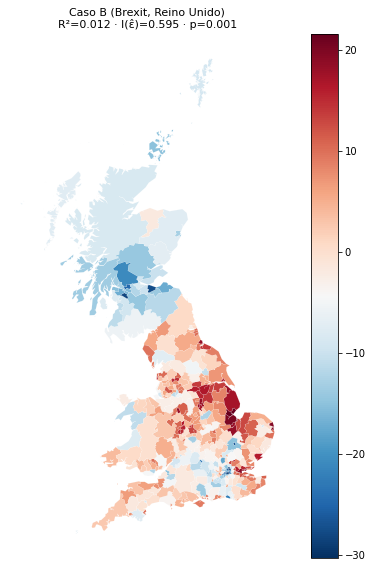

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 12 — Mapa de residuos: Caso B (Brexit, geografía real)
# ─────────────────────────────────────────────────────────────────────────────
gdf_b['resid_B'] = ols_b.u.flatten()

fig, ax = plt.subplots(figsize=(7, 8))
gdf_b.plot(column='resid_B', cmap='RdBu_r', legend=True, ax=ax,
           edgecolor='white', linewidth=0.1)
ax.set_title(f'Caso B (Brexit, Reino Unido)\nR²={ols_b.r2:.3f} · I(ε̂)={mi_b.I:.3f} '
             f'· p={mi_b.p_sim:.3f}', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

### El Moran Scatterplot, ahora sobre los residuos (Caso B)

Misma lógica que en el Caso A: eje X es el residuo estandarizado, eje Y es su rezago
espacial, y la pendiente de la recta es $I(\hat{\varepsilon})$. Comparen la forma de
esta nube contra la del Caso A — es la evidencia visual de la diferencia de intensidad
entre ambos diagnósticos.


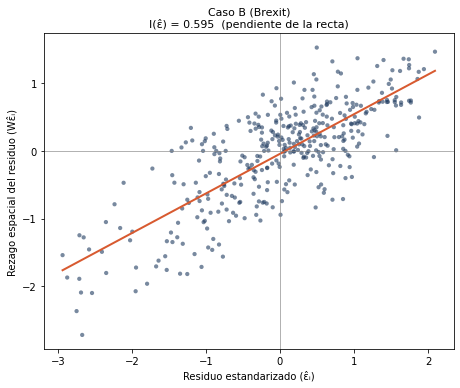

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 13 — Moran Scatterplot de los residuos: Caso B
# ─────────────────────────────────────────────────────────────────────────────
resid_b_std = (ols_b.u.flatten() - ols_b.u.flatten().mean()) / ols_b.u.flatten().std()
w_resid_b = w_b.sparse @ resid_b_std

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(resid_b_std, w_resid_b, s=18, alpha=0.6, color='#1E3A5F', edgecolor='none')
b, a0 = np.polyfit(resid_b_std, w_resid_b, 1)
xs = np.linspace(resid_b_std.min(), resid_b_std.max(), 50)
ax.plot(xs, a0 + b*xs, color='#D85A30', linewidth=2)
ax.axhline(0, color='gray', linewidth=0.6)
ax.axvline(0, color='gray', linewidth=0.6)
ax.set_xlabel('Residuo estandarizado (ε̂ᵢ)')
ax.set_ylabel('Rezago espacial del residuo (Wε̂ᵢ)')
ax.set_title(f'Caso B (Brexit)\nI(ε̂) = {mi_b.I:.3f}  (pendiente de la recta)', fontsize=11)
plt.tight_layout()
plt.show()

### Una extensión opcional: LISA de residuos (Caso B)

Moran I(ε̂) —el número global— responde "¿en promedio, hay dependencia espacial en lo
que el modelo no explicó?". Pero un número global no dice **dónde**. Así como
convirtieron el Moran I global de la variable cruda en LISA para localizar los
clústeres (Clase 7), pueden hacer exactamente lo mismo con los residuos: calcular un
**LISA de residuos**, que da un valor de significancia **por cada unidad**, no uno
solo para todo el territorio.

Esto tiene dos usos prácticos, uno antes de modelar y otro después:

- **Antes de elegir el modelo**: si el problema residual está concentrado solo en una
  parte del mapa (no repartido de forma pareja), eso sugiere heterogeneidad
  espacial — quizás no sea un único proceso SAR/SEM el que opera en toda el área de
  estudio, sino algo distinto en esa zona específica (un régimen espacial distinto,
  o una variable omitida muy localizada)
- **Después de estimar el modelo** (esto ya es trabajo de la sesión de Juan Carlos):
  correr LISA sobre los residuos del modelo espacial ya estimado, para confirmar si
  la dependencia quedó resuelta en todo el territorio o si persiste localizada en
  algún sector — un diagnóstico de validación que el número global no puede dar con
  la misma precisión geográfica

**Este bloque es material adicional, no parte de la cadena de decisión del modelo**
(esa cadena ya la completaron con Moran I(ε̂) + RLM-lag/error). Se entrega completo
para que Juan Carlos decida si lo incorpora a su módulo de estimación.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 14 — LISA de residuos: Caso B (Brexit)
# ─────────────────────────────────────────────────────────────────────────────
lisa_resid_b = Moran_Local(ols_b.u.flatten(), w_b, permutations=999, seed=11)
gdf_b['lisa_resid'] = clasificar_lisa(lisa_resid_b)

print('LISA de residuos — Caso B (Brexit):')
print(gdf_b['lisa_resid'].value_counts())

LISA de residuos — Caso B (Brexit):
No significativo    265
LL                   62
HH                   47
LH                    4
HL                    2
Name: lisa_resid, dtype: int64


/Users/juan_pablo_ospina/opt/anaconda3/lib/python3.9/site-packages/esda/moran.py:1059: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


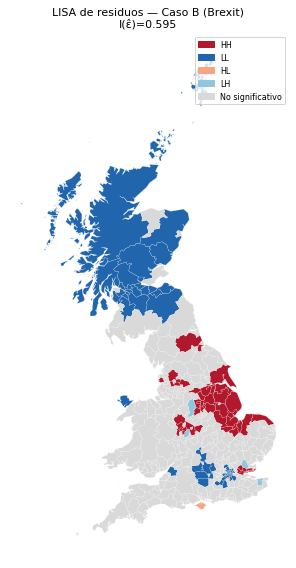

Nota: a mayor I(ε̂) global, más unidades caen en clústeres HH/LL significativos
— el Caso B (I(ε̂)≈0.59) muestra más clústeres que el Caso A (I(ε̂)≈0.23).


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 15 — Mapa de LISA de residuos: Caso B
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 8))
for categoria, color in colores_lisa.items():
    subset = gdf_b[gdf_b['lisa_resid'] == categoria]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.15)
handles = [mpatches.Patch(color=c, label=cat) for cat, c in colores_lisa.items()]
ax.set_title(f'LISA de residuos — Caso B (Brexit)\nI(ε̂)={mi_b.I:.3f}', fontsize=11)
ax.legend(handles=handles, loc='upper right', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.show()

print('Nota: a mayor I(ε̂) global, más unidades caen en clústeres HH/LL significativos')
print('— el Caso B (I(ε̂)≈0.59) muestra más clústeres que el Caso A (I(ε̂)≈0.23).')

### La tabla comparativa — el dispositivo pedagógico central

| | Caso A (ciclistas, Ospina et al., 2020) | Caso B (Brexit, datos reales) |
|---|---|---|
| **R²** | Moderado (0.38 con 6 variables; 0.79 con el modelo completo de 34) | Muy bajo (0.012) |
| **Moran I(ε̂)** | Significativo (0.23 con 6 variables; 0.16 con el modelo completo) | Muy alto (≈0.59) |
| **RLM-lag (robusto)** | No significativo | En el límite (p≈0.056) |
| **RLM-error (robusto)** | Significativo | Significativo |
| **Modelo sugerido** | SEM (con el modelo completo, ambos LM son significativos — revisar SDM) | Ambiguo — RLM-error domina más, pero RLM-lag no se descarta del todo (SDM sería razonable revisar) |
| **Lección** | Ni un ajuste moderado ni uno alto garantizan ausencia de dependencia espacial | R² bajo + I(ε̂) alto = el patrón está casi enteramente en el espacio, aunque el mecanismo exacto no siempre sea nítido |
| **Interpretación sustantiva** | Efectos de vecindario no observados en las variables del origen y la ruta del viaje | El resultado del referendo se agrupa fuertemente en el territorio — probablemente por una combinación de contagio directo y factores de contexto compartidos |

Son dos caras del mismo diagnóstico, y por eso son más poderosas juntas que por
separado: uno les enseña que el ajuste no certifica validez, el otro les enseña que
la falta de ajuste puede ser enteramente territorial.

**Una lección adicional, honesta:** con datos reales, el diagnóstico rara vez es tan
limpio como en un ejemplo de laboratorio. En el Caso B, ambos RLM (lag y error) dan
señales de dependencia espacial, con el error ligeramente más marcado. Esto no es un
defecto del método — es lo esperable cuando el fenómeno (un referendo nacional) tiene
más de un mecanismo espacial operando a la vez. Comparar **magnitudes**, no solo
significancia binaria, y considerar modelos que combinan ambos mecanismos (como SDM)
es parte del trabajo real de decidir el modelo — algo que Juan Carlos desarrollará.

**Importante:** aquí se detiene el trabajo de esta clase. No vamos a estimar SEM, SAR
ni SDM — solo a leer correctamente qué diagnóstico apunta hacia cuál. La estimación en
sí (máxima verosimilitud, variables instrumentales, interpretación de ρ y λ) la
desarrolla Juan Carlos Duque a partir de la Clase 10.


### Cómo funciona RLM-lag / RLM-error, por dentro

Hasta aquí usamos RLM-lag y RLM-error como una caja negra: se calculan, se mira cuál
es significativo, y eso sugiere un modelo. Vale la pena abrir esa caja un poco,
porque la lógica es elegante y no requiere estimar nada nuevo.

**El problema que resuelven:** Moran I(ε̂) les dice que *hay* dependencia espacial en
los residuos, pero no de qué tipo. Podría faltar un término que conecte a *y* con sus
vecinos (Wy, tipo SAR) o un término que conecte a los *errores* con sus vecinos (Wε,
tipo SEM). Ambos problemas producen el mismo síntoma — un Moran I(ε̂) significativo —
así que hace falta una prueba más específica que distinga entre ellos.

**La intuición del multiplicador de Lagrange:** la pregunta que resuelve es "si yo
*agregara* el término faltante (Wy o Wε) a mi modelo, ¿mejoraría significativamente
el ajuste?" — pero la responde **sin necesidad de estimar el modelo ampliado**. Usa
únicamente los residuos del OLS que ya corrieron. Es la parte más útil en la
práctica: no hace falta correr SAR ni SEM para saber si valdría la pena hacerlo.

Las versiones simples de la prueba son:

$$LM_{lag} = \frac{\left(\hat{\varepsilon}'W y / \hat{\sigma}^2\right)^2}{D} \qquad
LM_{error} = \left(\frac{\hat{\varepsilon}'W\hat{\varepsilon}}{\hat{\sigma}^2}\right)^2 \Big/ \, T$$

donde $D$ y $T$ son términos de escala que dependen de $W$ y de $X$. No es necesario
memorizar la fórmula exacta — lo importante es ver que **ambas se construyen a partir
de los mismos residuos $\hat{\varepsilon}$**, solo que $LM_{lag}$ los combina con $y$
(pregunta: "¿falta un contagio de la variable dependiente?") mientras que
$LM_{error}$ los combina consigo mismos vía $W$ (pregunta: "¿el error mismo tiene
estructura espacial?").

**Por qué existen versiones *robustas* (las que realmente usamos):** LM-lag simple y
LM-error simple tienen un problema práctico — están correlacionadas entre sí. Si el
verdadero problema es SAR pero calculan LM-error simple, con frecuencia también sale
significativo (y viceversa), porque cada prueba "contamina" un poco a la otra. Las
versiones **robustas** (`rlm_lag`, `rlm_error` en el código — las que ya usamos)
corrigen esa contaminación cruzada, aislando el efecto específico de cada mecanismo.
Por eso son las que hay que mirar en la práctica, y las que ya vienen calculadas en
`ols.rlm_lag` y `ols.rlm_error`.

### OLS no desaparece — se convierte en el punto de partida

Es común pensar que la econometría espacial *reemplaza* a OLS. No es así, y vale la
pena cerrarlo con esa precisión: la econometría espacial **comienza con OLS**,
analiza sus residuos, y solo si encuentra evidencia de estructura espacial pasa a un
modelo más complejo. OLS no es el problema — es el diagnóstico. Si sus residuos no
mostraran estructura espacial, OLS sería, sencillamente, el modelo correcto y no
haría falta nada más.

> La imagen del relieve lo resume bien: OLS intenta ajustar un terreno con una
> superficie plana. Si el terreno en efecto es plano, funciona perfectamente. Si el
> terreno tiene montañas y valles —como el patrón espacial que acaban de ver en los
> Casos A y B—, una superficie plana deja "relieve" sin explicar. Los residuos son el
> mapa de ese relieve que OLS no pudo representar. La econometría espacial que verán
> con Juan Carlos dibuja ese relieve.


---
## Los tres niveles de lo que han hecho hoy y en las clases anteriores

| Nivel | Pregunta | Herramientas |
|---|---|---|
| **Diagnóstico** | ¿Existe estructura espacial? | Moran, LISA, G\* |
| **Exploración** | ¿Cómo se relacionan y y su contexto? | WX, Moran bivariado |
| **Modelación** | ¿Cómo incorporamos formalmente esa estructura? | OLS → econometría espacial (Juan Carlos) |

Esta tabla resume por qué el curso está organizado como está: cada nivel depende del
anterior, y ningún nivel puede saltarse sin perder el fundamento del siguiente.

### El recorrido completo, de un vistazo

El siguiente esquema resume en una sola imagen toda la secuencia recorrida en el
bloque de diagnóstico — desde la primera pregunta ("¿cómo está organizado el
territorio?") hasta la pregunta con la que cierran hoy ("¿cómo la modelamos?"),
que es exactamente donde retoma Juan Carlos.


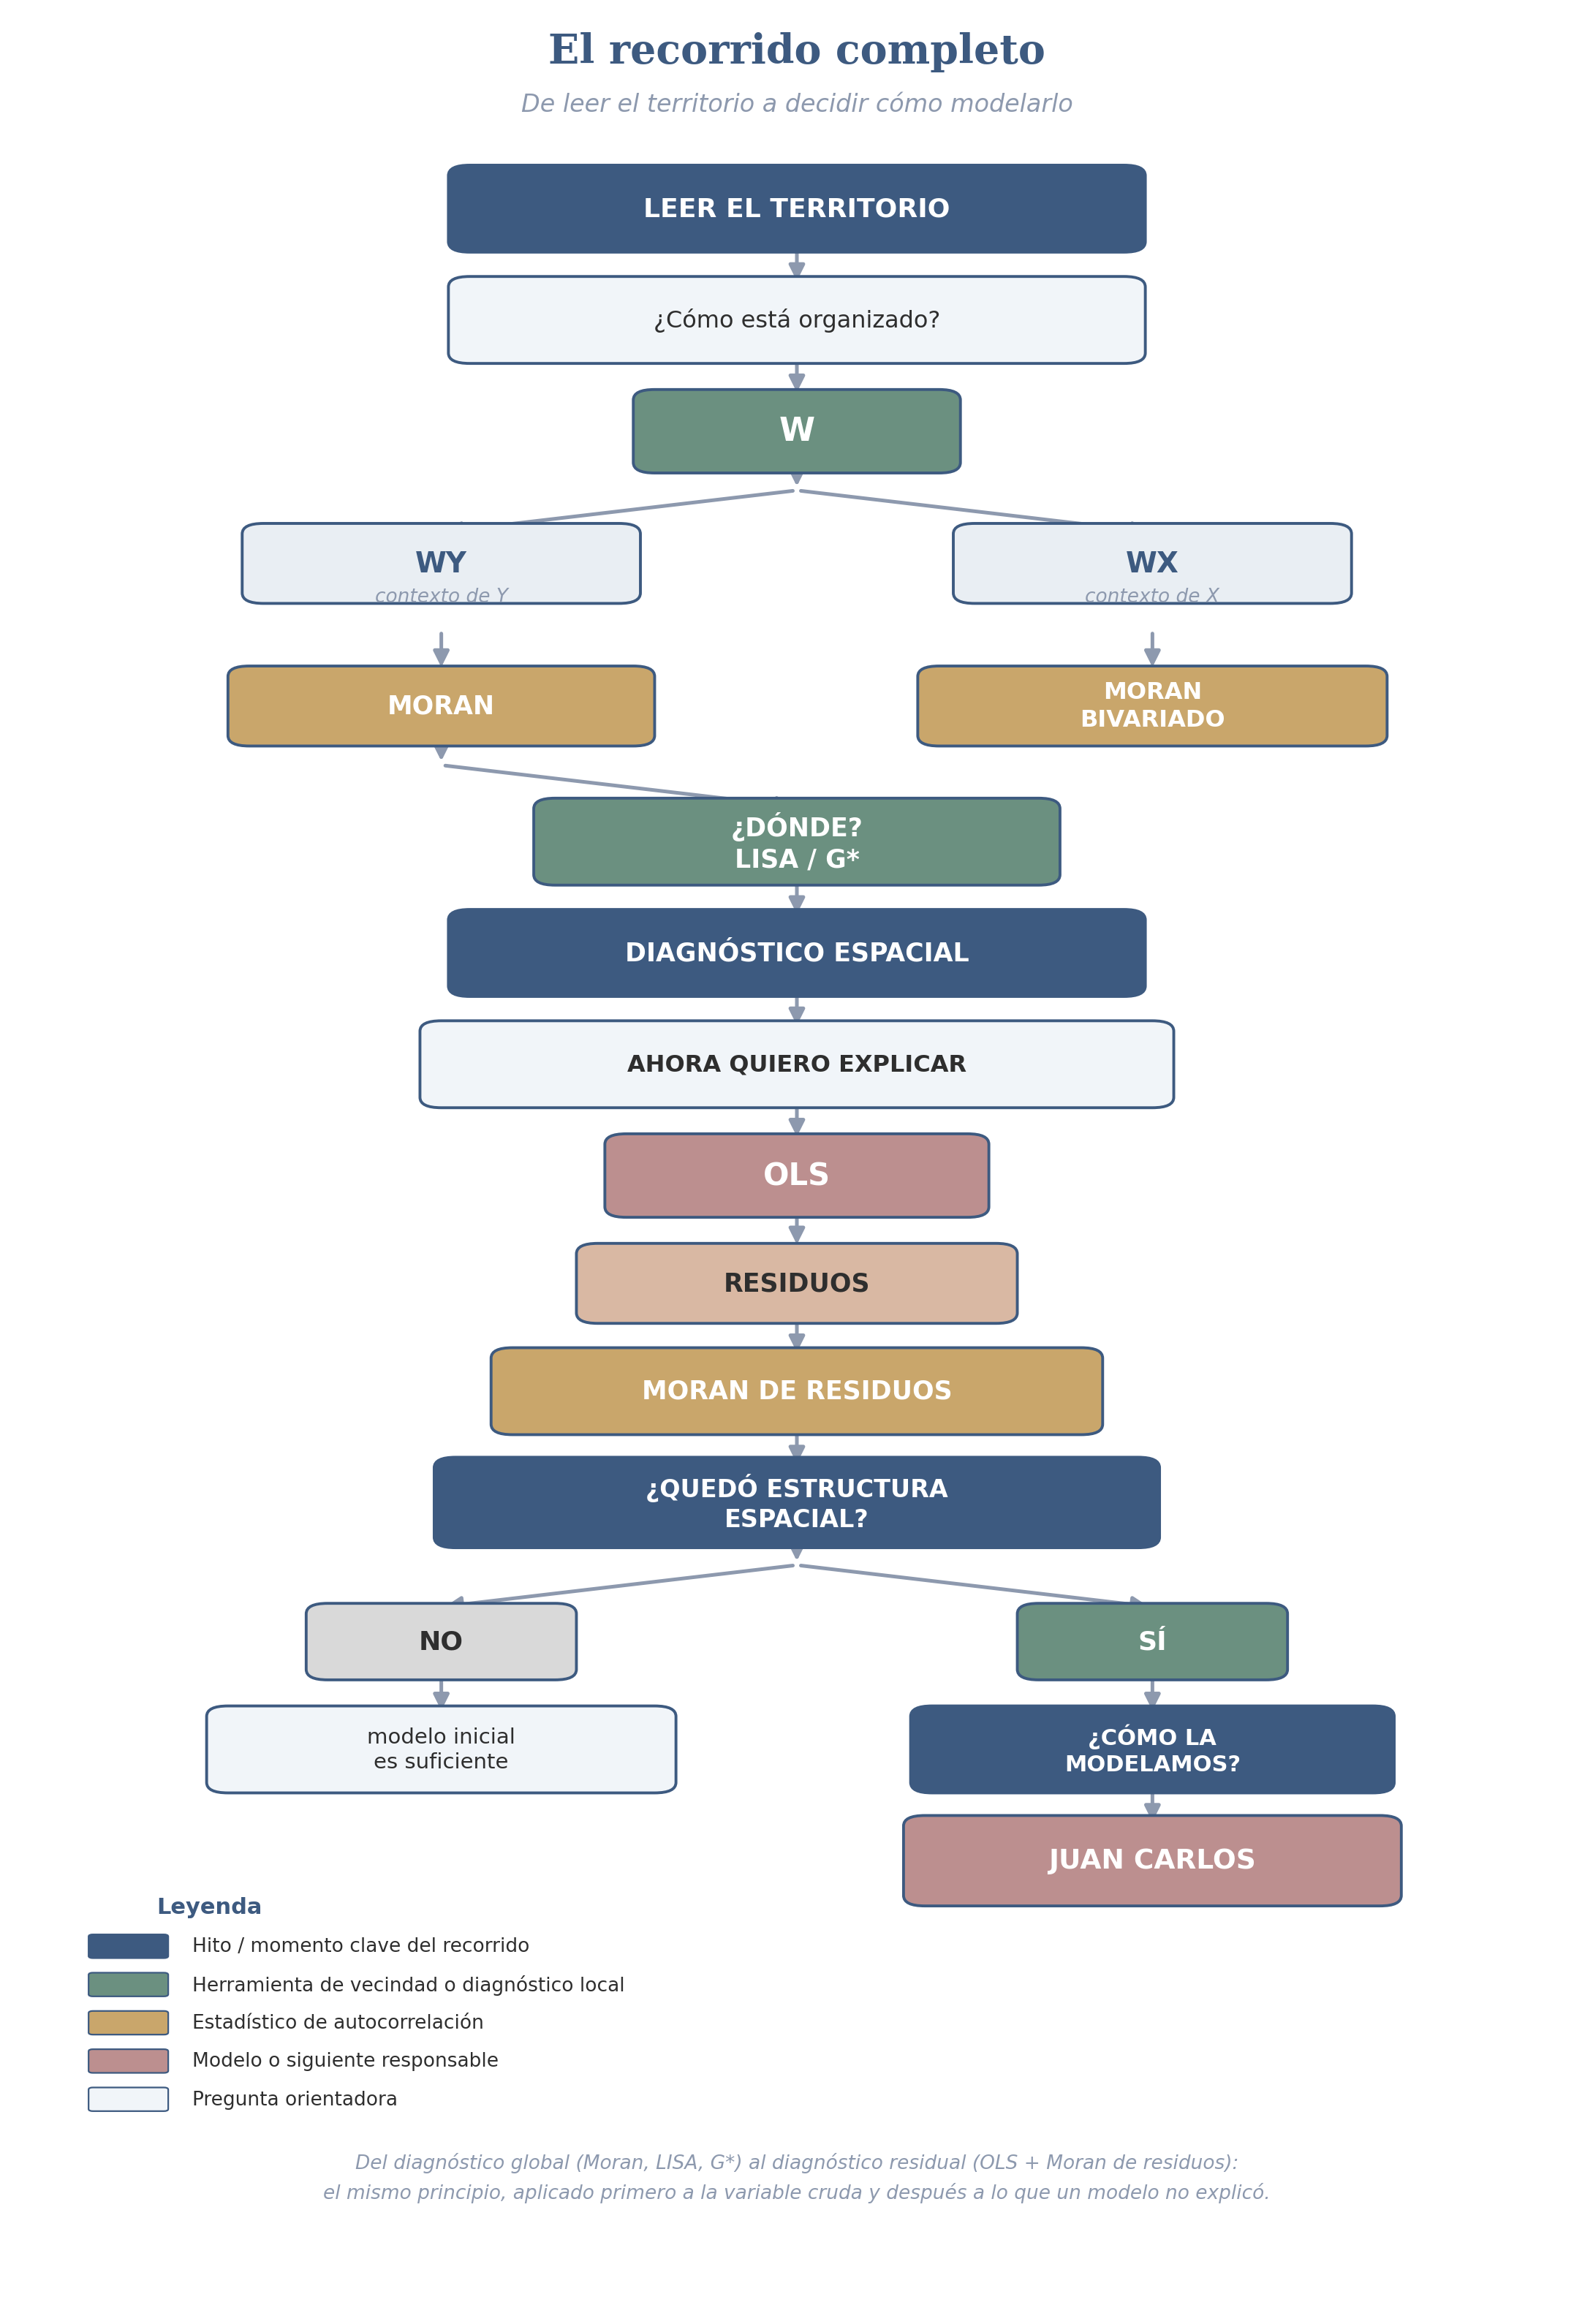

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA — El recorrido completo del bloque de diagnóstico (esquema de síntesis)
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import Image, display

display(Image(filename='img_flowchart_completo.png', width=650))

Todo lo que aparece en azul oscuro y teal en el esquema es lo que ya saben hacer.
La pregunta final ("¿cómo la modelamos?") es la que Juan Carlos va a desarrollar a
partir de la próxima sesión — la pregunta que se llevan de este módulo no es "¿qué
modelo debo correr?", es **"hemos encontrado estructura espacial: ¿cómo la
incorporamos formalmente en un modelo?"**


---
## Cierre de la sesión

Con G\*, la precisión sobre WX, y el diagnóstico OLS + Moran I(ε̂) + RLM completos, el
diagnóstico exploratorio y residual del curso queda cerrado: global, local por
similitud (LISA, Clase 7), local por concentración absoluta (G\*, hoy), y residual
(OLS + Moran I(ε̂) + RLM-lag/error, hoy). La estimación de los modelos espaciales
(secuencia LM completa, SAR/SEM/SDM) la retoma **Juan Carlos Duque** a partir de la
próxima sesión — y va a modelar exactamente la misma variable **y** cuya
concentración territorial y cuyo comportamiento residual acaban de diagnosticar hoy.
Conecta directamente con la entrega del **Hito 3**.


---
## Referencias

Anselin, L. (1988). *Spatial Econometrics: Methods and Models*. Kluwer Academic.

Anselin, L. (1995). Local Indicators of Spatial Association—LISA. *Geographical
Analysis*, 27(2), 93–115.

Getis, A. & Ord, J. K. (1992). The analysis of spatial association by use of
distance statistics. *Geographical Analysis*, 24(3), 189–206.

Ord, J. K. & Getis, A. (1995). Local spatial autocorrelation statistics:
distributional issues and an application. *Geographical Analysis*, 27(4), 286–306.

Ospina, J. P. et al. (2020). [Referencia completa del paper — hallazgo retrospectivo
tratado en esta clase].

Rey, S., Arribas-Bel, D. & Wolf, L. (2023). *Geographic Data Science with Python*,
cap. 6 y 8. Libre en geographicdata.science/book

---
*CM0866 · Juan Pablo Ospina Zapata · EAFIT 2026 · Clase 9*
